# Comparing Performance of TGradAMI vs. TGrad (for EVI and Rainfall data).


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import from local directory
import sys

sys.path.insert(0, '../src')
from TemporalGP.TGP.tgrad_ami import TGradAMI
from TemporalGP.TGP.t_graank import TGrad

Configure TGradAMI algorithm hyperparameters.

In [2]:
# Hyperparameters

# f_path = "../datasets/air_quality1k.csv"
# f_path = "../datasets/air_quality25.csv"

f_path_evi = "../datasets/ke_evi_data_2k.csv"
f_path_rain = "../datasets/ke_rain_data_2k.csv"

eq = False
min_sup = 0.1
tgt_col = 1
tgt_cols = [1, 2, 3, 4]
min_rep = 0.75
mi_err_margin = 0.0001
eval_mode = True
clustering_method = False

Visualize the top 5 rows of the dataset.

In [3]:
rain_data = pd.read_csv(f_path_rain)
evi_data = pd.read_csv(f_path_evi)


print(rain_data.head())
print("\n")
print(evi_data.head())

  Date (Jul-Sep)   NRB (mm)   KAK (mm)   MAK (mm)   WAJ (mm)
0        07-2000   22.01000   526.8000      18.45  12.219990
1        07-2001   57.55001   539.0801       0.90  13.440000
2        07-2002   45.17000   349.2700      20.47  15.320000
3        07-2003   77.08001   660.0199       2.27   8.940001
4        07-2004   16.48000   424.6999       0.71   4.819999


  Date (Jul-Sep)   NRB (EVI)   KAK (EVI)   MAK (EVI)   WAJ (EVI)
0        07-2000    0.094866    0.401556    0.160511    0.120766
1        07-2001    0.236884    0.417010    0.183184    0.152754
2        07-2002    0.243191    0.370047    0.206061    0.109228
3        07-2003    0.202896    0.423199    0.159602    0.109228
4        07-2004    0.119559    0.378931    0.178707    0.099040


Initialize TGrad and TGradAMI algorithms by creating objects for different target columns.

In [4]:
rain_tgrads_ami = []
evi_tgrads_ami = []
for t_col in tgt_cols:
    t_grad_rain = TGradAMI(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)
    t_grad_evi = TGradAMI(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)

    rain_tgrads_ami.append(t_grad_rain)
    evi_tgrads_ami.append(t_grad_evi)


rain_tgrads = []
evi_tgrads = []
for t_col in tgt_cols:
    t_grad_rain = TGrad(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep)
    t_grad_evi = TGrad(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep)

    rain_tgrads.append(t_grad_rain)
    evi_tgrads.append(t_grad_evi)

Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok


Run the algorithm for mining FTGPs (Fuzzy Temporal Gradual Patterns) in evaluation mode. The algorithm returns a number of results in a dict format.

In [5]:
for i, t_grad_rain in enumerate(rain_tgrads_ami):
    eval_dict_rain = t_grad_rain.discover_tgp(use_clustering=clustering_method, eval_mode=eval_mode)
    transform_steps = eval_dict_rain['Transformation Steps']
    eval_dict_evi = evi_tgrads_ami[i].discover_tgp(use_clustering=clustering_method, transformation_steps=transform_steps, eval_mode=eval_mode)


In [6]:
for i in range(len(rain_tgrads)):
    rain_tgrads[i].discover_tgp()
    evi_tgrads[i].discover_tgp()


* Tabulate the mined FTGPs with their corresponding parameters

## TGradAMI FTGPs

In [7]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads_ami]  # Collect all patterns into a list
res_rain_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_rain_df

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)+) +12.0 months",0.458,0.277,6.014,3.797,1,2.97
1,"NRB (mm)+, (KAK (mm)-) +12.0 months",0.542,0.328,6.602,4.338,1,3.084
2,"NRB (mm)+, (MAK (mm)+) +5.0 years",0.444,0.269,6.897,4.548,1,3.219
3,"NRB (mm)+, (MAK (mm)-) +5.0 years",0.549,0.332,5.917,3.668,1,3.386
4,"NRB (mm)+, (WAJ (mm)+) +12.0 months",0.379,0.229,6.034,3.629,1,2.853
...,...,...,...,...,...,...,...
59,"WAJ (mm)-, (NRB (mm)+) +3.0 years, (KAK (mm)+)...",0.479,0.36,6.802,4.56,1,2.592
60,"WAJ (mm)-, (NRB (mm)+) +2.0 years, (MAK (mm)+)...",0.389,0.292,7.378,4.98,1,2.808
61,"WAJ (mm)+, (MAK (mm)+) +3.0 years, (KAK (mm)+)...",0.205,0.154,8.769,4.022,1,1.942
62,"WAJ (mm)-, (MAK (mm)+) +3.0 years, (KAK (mm)+)...",0.305,0.229,7.466,4.959,1,2.888


In [8]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads_ami]  # Collect all patterns into a list
res_evi_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go
res_evi_df

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)+) +12.0 months",0.49,0.296,6.427,4.103,1,3.625
1,"NRB (EVI)+, (KAK (EVI)-) +12.0 months",0.51,0.308,6.244,4.114,1,3.628
2,"NRB (EVI)+, (MAK (EVI)+) +5.0 years",0.477,0.289,6.562,4.432,1,3.077
3,"NRB (EVI)+, (MAK (EVI)-) +5.0 years",0.523,0.316,6.125,3.779,1,3.131
4,"NRB (EVI)+, (WAJ (EVI)+) +12.0 months",0.418,0.253,5.516,3.836,1,2.435
...,...,...,...,...,...,...,...
61,"WAJ (EVI)-, (NRB (EVI)+) +2.0 years, (MAK (EVI...",0.279,0.209,7.472,5.247,1,2.014
62,"WAJ (EVI)+, (MAK (EVI)+) +3.0 years, (KAK (EVI...",0.221,0.166,6.381,4.408,1,2.657
63,"WAJ (EVI)-, (MAK (EVI)+) +3.0 years, (KAK (EVI...",0.258,0.194,8.265,4.886,1,3.045
64,"WAJ (EVI)+, (NRB (EVI)+) +3.0 years, (MAK (EVI...",0.158,0.119,6.933,4.753,1,2.458


## TGrad FTGPs

In [9]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads]
res_rain_df2 = pd.concat(patterns, ignore_index=True)
res_rain_df2

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)+) +12.0 months",0.476,0.435,7.882,5.182,1,1.571
1,"NRB (mm)+, (KAK (mm)-) +12.0 months",0.524,0.478,7.471,4.929,1,1.511
2,"NRB (mm)+, (MAK (mm)+) +12.0 months",0.463,0.423,8.037,5.311,1,2.602
3,"NRB (mm)+, (MAK (mm)-) +12.0 months",0.532,0.486,7.382,4.804,1,2.434
4,"NRB (mm)+, (WAJ (mm)+) +12.0 months",0.368,0.336,7.024,4.563,1,1.903
...,...,...,...,...,...,...,...
397,"WAJ (mm)-, (NRB (mm)+) +6.0 years, (MAK (mm)+)...",0.301,0.162,5.39,3.793,1,2.362
398,"WAJ (mm)+, (MAK (mm)+) +6.0 years, (KAK (mm)+)...",0.184,0.099,6.08,3.929,1,2.466
399,"WAJ (mm)-, (MAK (mm)+) +6.0 years, (KAK (mm)+)...",0.331,0.178,6.311,4.57,1,2.887
400,"WAJ (mm)+, (NRB (mm)+) +6.0 years, (MAK (mm)+)...",0.169,0.091,5.87,3.96,1,2.522


In [10]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads]
res_evi_df2 = pd.concat(patterns, ignore_index=True)
res_evi_df2

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)+) +12.0 months",0.463,0.423,7.346,4.892,1,2.303
1,"NRB (EVI)+, (KAK (EVI)-) +12.0 months",0.537,0.49,7.944,5.176,1,2.113
2,"NRB (EVI)+, (MAK (EVI)+) +12.0 months",0.519,0.474,7.667,5.134,1,2.165
3,"NRB (EVI)+, (MAK (EVI)-) +12.0 months",0.481,0.439,7.667,4.969,1,2.267
4,"NRB (EVI)+, (WAJ (EVI)+) +12.0 months",0.433,0.395,6.89,4.656,1,1.584
...,...,...,...,...,...,...,...
393,"WAJ (EVI)-, (NRB (EVI)+) +6.0 years, (MAK (EVI...",0.176,0.095,5.458,3.149,1,3.705
394,"WAJ (EVI)+, (MAK (EVI)+) +6.0 years, (KAK (EVI...",0.213,0.115,6.414,4.327,1,2.547
395,"WAJ (EVI)-, (MAK (EVI)+) +6.0 years, (KAK (EVI...",0.184,0.099,6.24,2.916,1,1.986
396,"WAJ (EVI)+, (NRB (EVI)+) +6.0 years, (MAK (EVI...",0.147,0.079,6.7,4.529,1,2.161


## Compute recall, precision and F1 score of extracted FTGPs

In [11]:
tgrad_ami_lst_pat_rain = []
for tgrad in rain_tgrads_ami:
    tgrad_ami_lst_pat_rain.extend(tgrad.gradual_patterns)

tgrad_ami_lst_pat_evi = []
for tgrad in evi_tgrads_ami:
    tgrad_ami_lst_pat_evi.extend(tgrad.gradual_patterns)

tgrad_lst_pat_rain = []
for tgrad in rain_tgrads:
    tgrad_lst_pat_rain.extend(tgrad.gradual_patterns)

tgrad_lst_pat_evi = []
for tgrad in evi_tgrads:
    tgrad_lst_pat_evi.extend(tgrad.gradual_patterns)

* True Positive (TP): an FTGP that appears in both **Rain** and **EVI** datasets with support >= 0.5
* False Positive (FP): an FTGP that appears in **Rain** dataset with support >= 0.5 but appears in **EVI** dataset with support < 0.5
* False Negative (FN): an FTGP that appears in **Rain** dataset with support < 0.5 but appears in **EVI** dataset with support >= 0.5
* True Negative (TN): an FTGP that appears in both **Rain** and **EVI** datasets with support < 0.5

In [12]:
res_tgrad_ami = {"TP": 0, "FP": 0, "FN": 0, "TN": 0, "Missing": 0}
res_tgrad = {"TP": 0, "FP": 0, "FN": 0, "TN": 0, "Missing": 0}

def exists_in(pat, lst):
    for pat_i in lst:
        if pat.is_similar_to(pat_i):
            return True
    return False

total = 0
already_seen = set()
for pat1 in tgrad_ami_lst_pat_rain:
    for pat2 in tgrad_ami_lst_pat_evi:
        if pat1.is_similar_to(pat2) and pat2 not in already_seen:
            already_seen.add(pat2)
            if pat1.support >= 0.5 and pat2.support >= 0.5:
                res_tgrad_ami["TP"] += 1
                total += 1
            elif pat1.support >= 0.5 > pat2.support:
                res_tgrad_ami["FP"] += 1
                total += 1
            elif pat1.support < 0.5 <= pat2.support:
                res_tgrad_ami["FN"] += 1
                total += 1
            elif pat1.support < 0.5 > pat2.support:
                res_tgrad_ami["TN"] += 1
                total += 1
res_tgrad_ami["Missing"] = len(tgrad_ami_lst_pat_rain) - total


total = 0
already_seen = set()
for pat1 in tgrad_lst_pat_rain:
    for pat2 in tgrad_lst_pat_evi:
        if pat1.is_similar_to(pat2) and pat2 not in already_seen:
            already_seen.add(pat2)
            if pat1.support >= 0.5 and pat2.support >= 0.5:
                res_tgrad["TP"] += 1
                total += 1
            elif pat1.support >= 0.5 > pat2.support:
                res_tgrad["FP"] += 1
                total += 1
            elif pat1.support < 0.5 <= pat2.support:
                res_tgrad["FN"] += 1
                total += 1
            elif pat1.support < 0.5 > pat2.support:
                res_tgrad["TN"] += 1
                total += 1
res_tgrad["Missing"] = len(tgrad_lst_pat_rain) - total

print(f"TGradAMI: {res_tgrad_ami}")
print(f"TGrad: {res_tgrad}")

TGradAMI: {'TP': 7, 'FP': 1, 'FN': 5, 'TN': 49, 'Missing': 2}
TGrad: {'TP': 46, 'FP': 38, 'FN': 27, 'TN': 273, 'Missing': 18}


<Figure size 800x500 with 0 Axes>

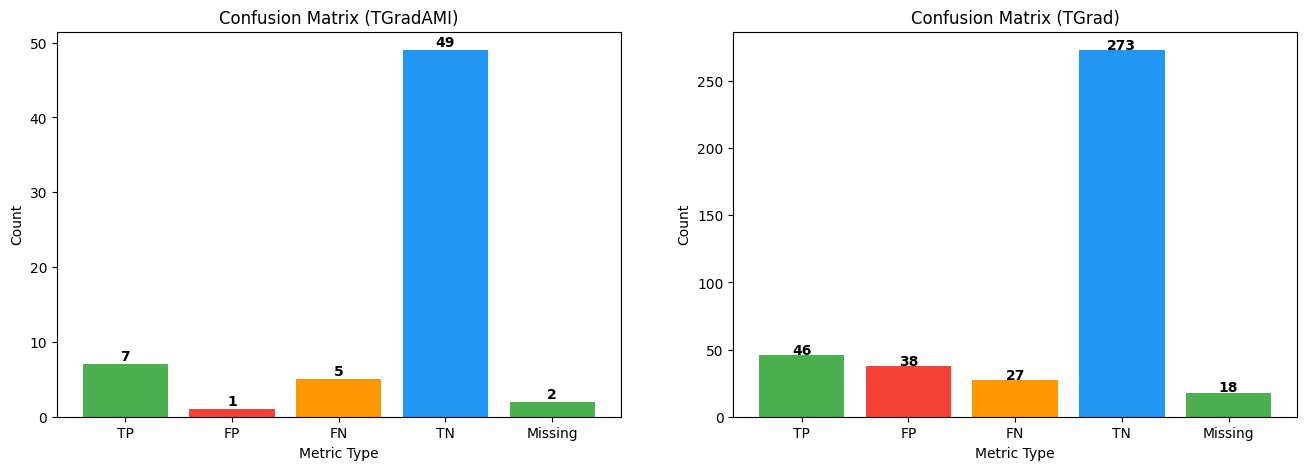

In [13]:
cat_tgrad_ami = list(res_tgrad_ami.keys())
cat_tgrad = list(res_tgrad.keys())
vals_tgrad_ami = list(res_tgrad_ami.values())
vals_tgrad = list(res_tgrad.values())

# Create plot
plt.figure(figsize=(8, 5))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
colors = ['#4CAF50', '#F44336', '#FF9800', '#2196F3'] # Green, Red, Orange, Blue
ax1.bar(cat_tgrad_ami, vals_tgrad_ami, color=colors)
ax2.bar(cat_tgrad, vals_tgrad, color=colors)

# Add styling
ax1.set_title('Confusion Matrix (TGradAMI)')
ax1.set_xlabel('Metric Type')
ax1.set_ylabel('Count')
ax2.set_title('Confusion Matrix (TGrad)')
ax2.set_xlabel('Metric Type')
ax2.set_ylabel('Count')

# Add value labels on top of bars
for i, v in enumerate(vals_tgrad_ami):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

for i, v in enumerate(vals_tgrad):
    ax2.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.show()

In [14]:
def compute_performance(tp, fp, fn):
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return round(precision, 3), round(recall,3), round(f1,3)

In [15]:
tgrad_ami_pre, tgrad_ami_rec, tgrad_ami_f1 = compute_performance(res_tgrad_ami["TP"], res_tgrad_ami["FP"], res_tgrad_ami["FN"])
tgrad_pre, tgrad_rec, tgrad_f1 = compute_performance(res_tgrad["TP"], res_tgrad["FP"], res_tgrad["FN"])

print(f"TGradAMI\nPrecision: {tgrad_ami_pre}, Recall: {tgrad_ami_rec}, F1: {tgrad_ami_f1}\n")
print(f"TGrad\nPrecision: {tgrad_pre}, Recall: {tgrad_rec}, F1: {tgrad_f1}")

TGradAMI
Precision: 0.875, Recall: 0.583, F1: 0.7

TGrad
Precision: 0.548, Recall: 0.63, F1: 0.586
